# Simple End-to-End Example

Ici on présente un exemple simple et complet avec une collection de traces simulées à partir d'un réseau.
Le réseau est un extrait de la BDTOPO située sur un versant de montagne en face de la ville de Chamonix.
Les données du réseau sont téléchargées par flux WFS.

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Import de tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import de OFNP
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import tracklib as tkl

Number of edges= 11
Number of nodes= 11



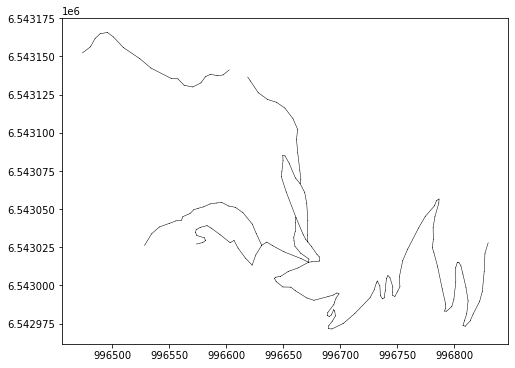

In [2]:
fmt = tkl.NetworkFormat({
       "pos_edge_id": 0,
       "pos_source": 1,
       "pos_target": 2,
       "pos_wkt": 4,
       "srid": "ENU",
       "separator": ",",
       "header": 1})
network = tkl.NetworkReader.readFromFile("/home/md_vandamme/4_RESEAU/ZTEMP/network.txt", fmt, verbose=False)

plt.figure(figsize=(8, 6))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)

print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
print ('')

In [3]:
for edge in network:
    if edge.geom.length() > 2000:
        print (edge.geom.length(), edge.geom.getListAnalyticalFeatures())

100% (50 of 50) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


------------------------------------------------------------
37 (74.0 %) tracks generated on network
------------------------------------------------------------


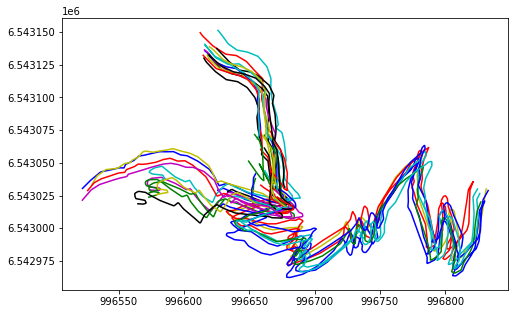

In [4]:
#
noiser = tkl.NoiseProcess(amps=5, kernels=tkl.ExponentialKernel(500))

# generate simulated trajectories from the network 
collection = tkl.generateTracksOnNetwork(network, N=50, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

# add 3 attributes
for idx, track in enumerate(collection):
    track.createAnalyticalFeature('num', idx+1)
    track.createAnalyticalFeature('user_id', idx+1)
    track.createAnalyticalFeature('track_id', idx+1)

#
plt.figure(figsize=(8, 5))
collection.plot(append=plt)

## Dossier de stockage des résultats

In [5]:
from ofnp import setupenv

RESPATH = r'/home/md_vandamme/4_RESEAU/ZTEMP/'

setupenv(RESPATH)


## Step 1 : segment and resample

In [6]:
from ofnp import segmentation_resample

# Paramètre : Nombre de points minimum pour un morceau de trace au moment du découpage
#             si le nombre n'est pas atteint, le morceau de trace est oublié
NB_OBS_MIN           = 10

# Paramètre : Distance en mètres entre 2 points, si supérieure au seuil on coupe la trace
DIST_MAX_2OBS        = 50


RESAMPLE_SIZE_GRID = 1
RESAMPLE_SIZE_FUSION = 5

# =============================================================================
#  On définit un format pour le stockage des traces modifiées dans le pipeline
fmt = tkl.TrackFormat({'ext': 'CSV',
                           'srid': 'ENU',
                           'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                           'time_fmt': '2D/2M/4Y 2h:2m:2s',
                           'separator': ';',
                           'header': 0,
                           'cmt': '#',
                           'read_all': True})
segmentation_resample(RESPATH, collection, fmt, NB_OBS_MIN, DIST_MAX_2OBS,
                    RESAMPLE_SIZE_GRID, RESAMPLE_SIZE_FUSION)



Starting segmentation and resampling...
Starting segmentation ...
    Number of tracks after segmentation: 37
Finished saving segmented tracks.
Starting resampling ...
    Number of tracks to resample:  198
    Number of tracks after resampling: 198
    Number of tracks after resampling: 198
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.


## Step 2 : calculs des cartes de densités, de constraste et binaire

In [7]:
from ofnp import density_polygonize

RESAMPLE_SIZE_GRID = 1

G1_SIZE = 2
G2_SIZE = 30 # 50

SEUIL_DENSITE = 360  # 15 - 1000
SEUIL_SURFACE = 1000 # m2 - 50000 - 7000

f = 2   # Cut factor

# =============================================================================
#
density_polygonize(RESPATH, G1_SIZE, G2_SIZE, SEUIL_DENSITE, SEUIL_SURFACE,
                       prefix='PT', rep='resample_grid', f=2)



 11% (23 of 198) |##                     | Elapsed Time: 0:00:00 ETA:   0:00:01

----------------------------------------------------------------------
STAGE 2 :                                   
   - Calcul d’une carte de densité à partir des traces GNSS 
   - De la vectorisation on extrait une ligne centrée ≡ arc de la topologie 
----------------------------------------------------------------------


100% (198 of 198) |######################| Elapsed Time: 0:00:02 Time:  0:00:020000


Number files to load:  198
Starting to compute aggregates ...
Temps d'exécution en s: 14.53055477142334
Fin des calculs des cartes de densités, de constraste et binaire.
Files '/home/md_vandamme/4_RESEAU/ZTEMP/image/erosion_PT.tif' and '/home/md_vandamme/4_RESEAU/ZTEMP/image/dilatation_PT.tif' deleted successfully.
Files road_surface.shp deleted successfully.
Files road_surface_lissee.shp deleted successfully.
Files surface.shp deleted successfully.
Files '/home/md_vandamme/4_RESEAU/ZTEMP/network/squelette_PT.shp' deleted successfully.
Temps d'exécution en s: 19.329431533813477
Fin de l'ouverture.
Temps d'exécution en s: 0.11515688896179199
Fin de la vectorisation.
une géométrie intérieure
Temps d'exécution en s: 0.3058159351348877
Fin du lissage de road surface.
*[2026-04-10 21:40:12.177284]  Importing polygons from: [/home/md_vandamme/4_RESEAU/ZTEMP/image/road_surface_lissee_PT.shp]... 

100% (315 of 315) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (167 of 167) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (148 of 148) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (303 of 303) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (168 of 168) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (156 of 156) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1250 of 1250) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (743 of 743) |######################| Elapsed Time: 0:00:00 Time:  0:00:0000
100% (724 of 724) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (960 of 960) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 559) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--

done

*[2026-04-10 21:40:12.214983]  Center line computation

*[2026-04-10 21:40:12.215294]  Upsampling polygon borders...

*[2026-04-10 21:40:12.223286]  Computing polygon skeleton...

*[2026-04-10 21:40:12.241308]  Filtering skeleton to form center line...

*[2026-04-10 21:40:12.245036]  Upsampling polygon borders...

*[2026-04-10 21:40:12.254096]  Computing polygon skeleton...

*[2026-04-10 21:40:12.268685]  Filtering skeleton to form center line...

*[2026-04-10 21:40:12.272872]  Upsampling polygon borders...

*[2026-04-10 21:40:12.295071]  Computing polygon skeleton...

*[2026-04-10 21:40:12.353167]  Filtering skeleton to form center line...

*[2026-04-10 21:40:12.368601]  Upsampling polygon borders...

*[2026-04-10 21:40:12.387687]  Computing polygon skeleton...


100% (559 of 559) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (545 of 545) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (225 of 225) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (116 of 116) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (100 of 100) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1822 of 1822) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1077 of 1077) |####################| Elapsed Time: 0:00:00 Time:  0:00:000:00
100% (1062 of 1062) |####################| Elapsed Time: 0:00:00 Time:  0:00:00



*[2026-04-10 21:40:12.434665]  Filtering skeleton to form center line...

*[2026-04-10 21:40:12.444203]  Upsampling polygon borders...

*[2026-04-10 21:40:12.450739]  Computing polygon skeleton...

*[2026-04-10 21:40:12.460380]  Filtering skeleton to form center line...

*[2026-04-10 21:40:12.463520]  Upsampling polygon borders...

*[2026-04-10 21:40:12.494030]  Computing polygon skeleton...

*[2026-04-10 21:40:12.576190]  Filtering skeleton to form center line...

*[2026-04-10 21:40:12.597120]  Exporting center line to: [/home/md_vandamme/4_RESEAU/ZTEMP/network/squelette_PT.shp]... done
Temps d'exécution en s: 0.46273350715637207
Fin du calcul de la center line.
Fin des calculs de vectorisation et squelette.


<AxesSubplot:>

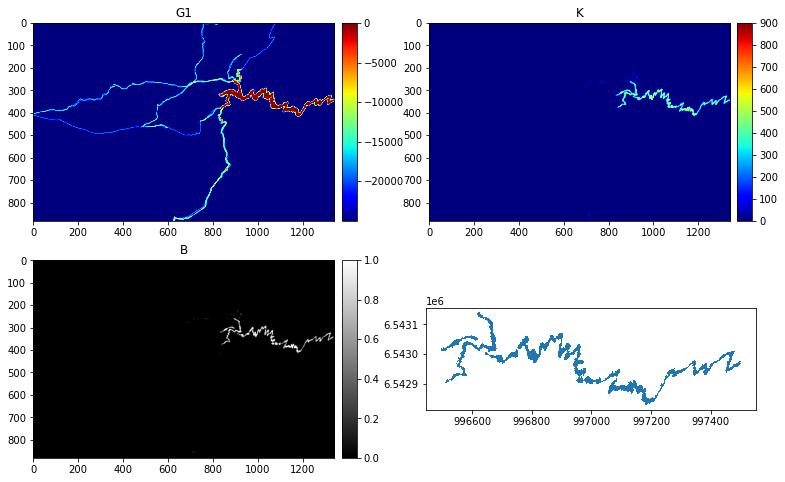

In [10]:
plt.figure(figsize=(13, 8))

ax1 = plt.subplot2grid((2, 2), (0, 0))
rasterG1 = tkl.RasterReader.readFromAscFile(RESPATH + 'image/G1_PT.asc', name='G1', separator='\t')
mapDensity = rasterG1.getAFMap('G1')
mapDensity.plotAsImage(cmap='jet', append=ax1)

ax2 = plt.subplot2grid((2, 2), (0, 1))
rasterK = tkl.RasterReader.readFromAscFile(RESPATH + 'image/K_PT.asc', name='K', separator='\t')
mapContraste = rasterK.getAFMap('K')
mapContraste.plotAsImage(cmap='jet', append=ax2)

ax3 = plt.subplot2grid((2, 2), (1, 0))
rasterB = tkl.RasterReader.readFromAscFile(RESPATH + 'image/B_PT.asc', name='B', separator='\t')
mapBinaire = rasterB.getAFMap('B')
mapBinaire.plotAsImage(append=ax3)

import geopandas as gpd
# charger le shapefile
gdf = gpd.read_file(RESPATH + 'image/road_surface_PT.shp')
ax4 = plt.subplot2grid((2, 2), (1, 1))
gdf.plot(ax=ax4)